### **Metropolis-Hastings**
Implement a Metropolis-Hastings algorithm for a 2D Gaussian Mixture model, including defining the target and proposal distributions, implementing the sampling algorithm, and analyzing the generated samples (mean, standard deviation, correlation).

Define Target Distribution (2D Gaussian Mixture)

Define the parameters (means, covariance matrices, and weights) for a 2D Gaussian Mixture Model, and implement its PDF.


In [ ]:
import numpy as np
from scipy.stats import multivariate_normal as mvn

# Define parameters for the 2D Gaussian Mixture Model

# Component 1
mu1 = np.array([-2, -2])
cov1 = np.array([[0.8, 0.4],[0.4, 0.8]])
weight1 = 0.3

# Component 2
mu2 = np.array([2, 2])
cov2 = np.array([[0.6, -0.2],[-0.2, 0.6]])
weight2 = 0.4

# Component 3
mu3 = np.array([-2, 2])
cov3 = np.array([[0.5, 0.1],[0.1, 0.5]])
weight3 = 0.3

# Store parameters in lists
mus_gmm = [mu1, mu2, mu3]
covs_gmm = [cov1, cov2, cov3]
weights_gmm = [weight1, weight2, weight3]

# Ensure weights sum to 1 (or close to 1 due to floating point arithmetic)
# This is a check, not an adjustment in this step
assert np.isclose(np.sum(weights_gmm), 1.0), f"Weights do not sum to 1: {np.sum(weights_gmm)}"

# Implement the PDF function for the GMM
def target_pdf_gmm(x):
    '''
    Args:
        x (np.ndarray): A 2D point (e.g., np.array([x_val, y_val])).
    Returns:
        float: The PDF value at point x.
    '''
    pdf_value = 0.0
    for i in range(len(mus_gmm)):
        pdf_value += weights_gmm[i]*mvn.pdf(x, mean=mus_gmm[i], cov=covs_gmm[i])
    return pdf_value

print("Defined 2D Gaussian Mixture Model Parameters:")
for i in range(len(mus_gmm)):
    print(f"\nComponent {i+1}: \n"
    f"  Mean (mu): {mus_gmm[i]}"
    f"  Covariance (cov):\n{covs_gmm[i]}"
    f"  Weight: {weights_gmm[i]}")
print(f"\nTotal weights sum: {np.sum(weights_gmm)}")

Defined 2D Gaussian Mixture Model Parameters:

Component 1: 
  Mean (mu): [-2 -2]  Covariance (cov):
[[0.8 0.4]
 [0.4 0.8]]  Weight: 0.3

Component 2: 
  Mean (mu): [2 2]  Covariance (cov):
[[ 0.6 -0.2]
 [-0.2  0.6]]  Weight: 0.4

Component 3: 
  Mean (mu): [-2  2]  Covariance (cov):
[[0.5 0.1]
 [0.1 0.5]]  Weight: 0.3

Total weights sum: 1.0


Define Proposal Distribution

Implement a proposal distribution function for the Metropolis-Hastings algorithm. A common choice is a symmetric Gaussian distribution centered at the current sample.


In [ ]:
import numpy as np
from scipy.stats import multivariate_normal as mvn

# Define standard deviation for the isotropic 2D Gaussian proposal distribution
proposal_std_dev_mh = 0.5
proposal_cov_mh = np.eye(2) * proposal_std_dev_mh**2 # Isotropic covariance matrix

# Function for the proposal sampler
def proposal_sampler(current_sample):
    '''
    Generates a new proposed sample from an isotropic 2D Gaussian centered at the current sample.
    Args:
        current_sample (np.ndarray): The current state (2D point).
    Returns:
        np.ndarray: The proposed new sample (2D point).
    '''
    return np.random.multivariate_normal(mean=current_sample, cov=proposal_cov_mh)

# Function for the proposal PDF
def proposal_pdf_mh(x, center):
    '''
    Calculates the PDF of the isotropic 2D Gaussian proposal distribution.
    Args:
        x (np.ndarray): The point (proposed sample) for which to get the PDF.
        center (np.ndarray): The mean of the proposal distribution (sample).
    Returns:
        float: The PDF value at point x.
    '''
    return mvn.pdf(x, mean=center, cov=proposal_cov_mh)

# 4. Print the chosen standard deviation for the proposal distribution
print(f"Proposal Distribution Parameters (Metropolis-Hastings): \n"
f"  Isotropic Standard Deviation: {proposal_std_dev_mh} \n"
f"  Covariance Matrix:\n{proposal_cov_mh}")

Proposal Distribution Parameters (Metropolis-Hastings): 
  Isotropic Standard Deviation: 0.5 
  Covariance Matrix:
[[0.25 0.  ]
 [0.   0.25]]


Metropolis-Hastings Algorithm

This involves initializing a starting point, iteratively proposing new states from the proposal distribution, calculating the acceptance ratio, and accepting or rejecting the proposed state. Include parameters for the number of samples and a burn-in period.


In [ ]:
import numpy as np

# Initialize a starting point for the Markov Chain
current_state = np.array([0.0, 0.0]) # Start at the origin

# Define the total number of iterations and burn-in period
num_iterations_mh = 100000
burn_in_mh = 10000

# Create an empty list to store the accepted samples
mh_samples = []

# Start the Metropolis-Hastings sampling loop
for i in range(num_iterations_mh):
    # a. Propose a new state
    proposed_state = proposal_sampler(current_state)

    # b. Calculate the acceptance ratio (alpha)
    # Since the proposal is symmetric, we only need the target PDF ratio
    target_pdf_current = target_pdf_gmm(current_state)
    target_pdf_proposed = target_pdf_gmm(proposed_state)

    # Handle cases where target_pdf_current might be zero (unlikely with GMM, but good practice)
    if target_pdf_current == 0:
        # If current state has zero probability, and proposed is not zero, always accept
        if target_pdf_proposed > 0:
            alpha = 1.0
        else:
            # Both are zero, stay put (effectively alpha=0 if we don't move)
            alpha = 0.0 # Or 1.0 if we allow moving between zero-prob areas (not typical for cont. dist)
    else:
        alpha = min(1.0, target_pdf_proposed / target_pdf_current)

    # c. Accept or reject the proposed state
    if np.random.rand() < alpha:
        current_state = proposed_state

    # d. If beyond burn-in, append the current_state to samples
    if i >= burn_in_mh:
        mh_samples.append(current_state)

# 5. Convert the list of samples to a NumPy array
mh_samples = np.array(mh_samples)

# 6. Print verification
print(f"Generated {len(mh_samples)} samples after burn-in. \n"
f"First 5 Metropolis-Hastings samples:\n{mh_samples[:5].round(2)} \n"
f"Mean of samples: {np.mean(mh_samples, axis=0).round(2)} \n"
f"Standard deviation of samples: {np.std(mh_samples, axis=0).round(2)}")

Generated 90000 samples after burn-in. 
First 5 Metropolis-Hastings samples:
[[2.05 0.95]
 [1.29 1.48]
 [1.29 1.48]
 [1.6  1.19]
 [1.6  1.19]] 
Mean of samples: [-0.44  0.81] 
Standard deviation of samples: [2.12 2.  ]


Analyze Metropolis-Hastings Samples

Calculate and print key statistics such as the mean and standard deviation for each dimension, and if applicable, the correlation between dimensions.


In [ ]:
import numpy as np

# Calculate the correlation matrix
correlation_matrix = np.corrcoef(mh_samples, rowvar=False)

# Extract the correlation coefficient between the two dimensions (X1 and X2)
# The correlation matrix for 2 variables is:
# [[  1      corr(X1,X2)  ]
#  [corr(X2,X1)    1      ]]
correlation_coefficient = correlation_matrix[0, 1]

print(f"Correlation between X1 and X2 in Metropolis-Hastings samples: {correlation_coefficient:.2f}")

Correlation between X1 and X2 in Metropolis-Hastings samples: 0.46


Visualize Sampling Results

Generate a contour plot of the target 2D Gaussian Mixture distribution and overlay a scatter plot of the accepted samples from the Metropolis-Hastings algorithm to visually assess the sampling coverage and convergence.

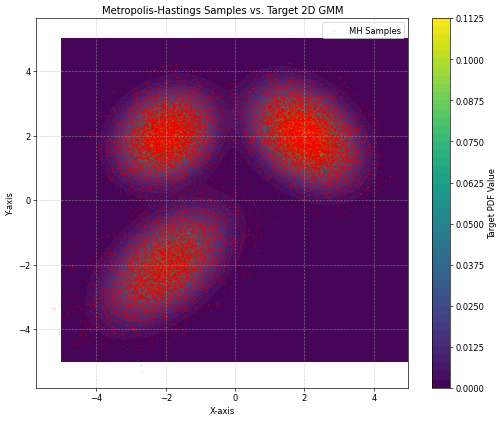

In [ ]:
import matplotlib.pyplot as plt

# A 2D grid of points
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_range, y_range)

# The PDF value for each point in the grid
Z = np.zeros(X.shape)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = target_pdf_gmm(np.array([X[i, j], Y[i, j]]))

# The contour plot
plt.figure(figsize=(10, 8), dpi=60)
plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(label='Target PDF Value')

# Overlay a scatter plot of the mh_samples
plt.scatter(mh_samples[:, 0], mh_samples[:, 1], s=1, alpha=0.1, color='red', label='MH Samples')

plt.title('Metropolis-Hastings Samples vs. Target 2D GMM')
plt.xlabel('X-axis') ; plt.ylabel('Y-axis')
plt.legend() ; plt.grid(True, linestyle='--', alpha=0.6) ; plt.show()

**Target Distribution Definition**: A 2D Gaussian Mixture Model (GMM) was successfully defined with three components:

**Proposal Distribution Definition**: An isotropic 2D Gaussian distribution was used as the proposal, centered at the current sample, with a standard deviation of 0.5, resulting in a covariance matrix of [[0.25, 0.0], [0.0, 0.25]].

**Metropolis-Hastings Sampling**:
- The algorithm ran for 100,000 iterations with a burn-in period of 10,000 iterations.
- A total of 90,000 samples were generated and collected after burn-in.

**Visual Validation**: A contour plot of the target GMM with overlaid Metropolis-Hastings samples visually confirmed that the samples effectively cover the high-probability regions of the complex target distribution, indicating good sampling coverage and convergence.

The Metropolis-Hastings algorithm successfully sampled from the multimodal 2D Gaussian Mixture Model, providing samples whose statistics (mean, standard deviation, and correlation) offer a quantitative summary of the target distribution and whose visual distribution aligns with the target PDF.

To further optimize the sampling process, future steps could involve tuning the proposal distribution's standard deviation (currently 0.5) to achieve a more ideal acceptance rate (typically between 20-50% for continuous distributions), or evaluating convergence more rigorously using trace plots and autocorrelation functions.
